# Week 5 — House Price Prediction (Linear & Logistic Regression)
**Intern:** Sankalpa Parajuli | **Track:** AI/ML Internship

**Workflow:** load data → clean → split → train → predict → evaluate.

**Dataset:** California Housing (loaded from a public URL). Target = `median_house_value`.

## 1. Theory (short)
**Linear Regression** fits a line: `ŷ = w·x + b`.

**Cost function (MSE):** `J(w,b) = (1/n) Σ (ŷᵢ − yᵢ)²` — the average squared error.

**Gradient descent** updates the weights to reduce the cost:
`w := w − α · ∂J/∂w`, where `α` is the learning rate. Repeat until the cost stops going down.

**Logistic Regression** is for classification. It passes the linear output through a sigmoid
`σ(z) = 1/(1+e^−z)` to get a probability between 0 and 1.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_breast_cancer
sns.set_style('whitegrid')

## 2. Load & look at the data

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv')
print(df.shape)
df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
print(df.isnull().sum()[df.isnull().sum()>0])
df.describe().T

total_bedrooms    207
dtype: int64


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


## 3. Data preparation
- Fill missing `total_bedrooms` with the median
- One-hot encode `ocean_proximity` (text column)

In [4]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']
print(X.shape)

(20640, 12)


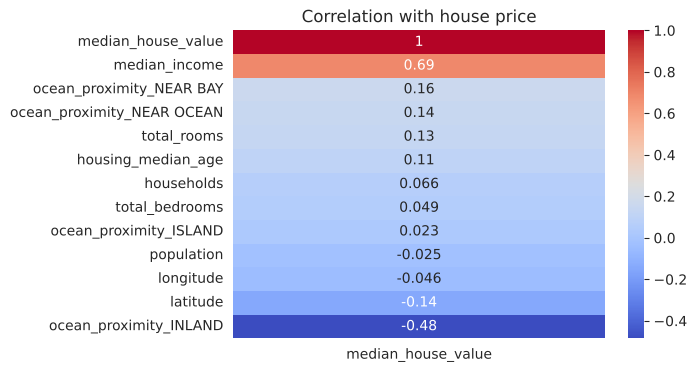

In [5]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr()[['median_house_value']].sort_values('median_house_value', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation with house price'); plt.show()

## 4. Train / test split (80/20) and scaling

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_train)          # fit on train only
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)
print(X_train.shape, X_test.shape)

(16512, 12) (4128, 12)


## 5. Train Linear Regression

In [7]:
lin = LinearRegression().fit(X_train_s, y_train)
pred = lin.predict(X_test_s)

## 6. Evaluate (MAE, MSE, RMSE, R²)

In [8]:
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)
pd.DataFrame({'Metric':['MAE','MSE','RMSE','R²'],'Value':[mae,mse,rmse,r2]}).round(3)

,Metric,Value
0,MAE,5.067074e+04
1,MSE,4.908477e+09
2,RMSE,7.006052e+04
3,R²,6.250000e-01


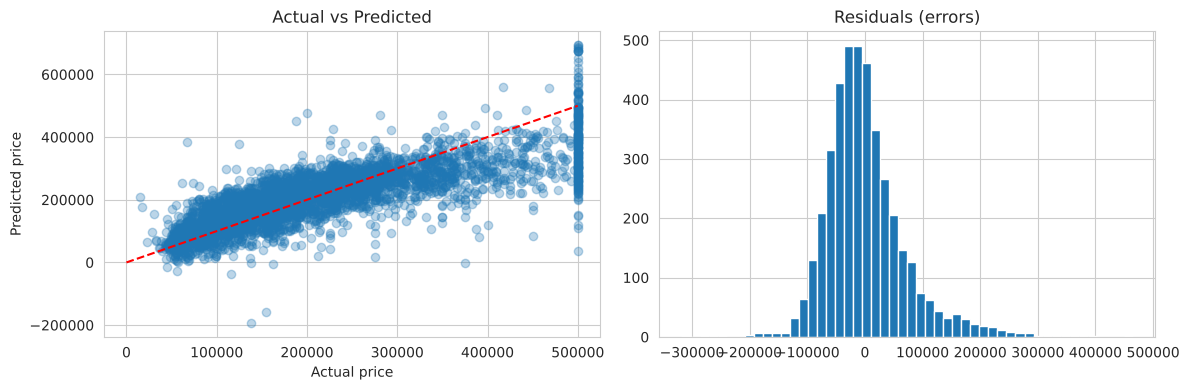

In [9]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].scatter(y_test, pred, alpha=0.3); ax[0].plot([0,5e5],[0,5e5],'r--')
ax[0].set_xlabel('Actual price'); ax[0].set_ylabel('Predicted price'); ax[0].set_title('Actual vs Predicted')
ax[1].hist(y_test-pred, bins=50); ax[1].set_title('Residuals (errors)')
plt.tight_layout(); plt.show()

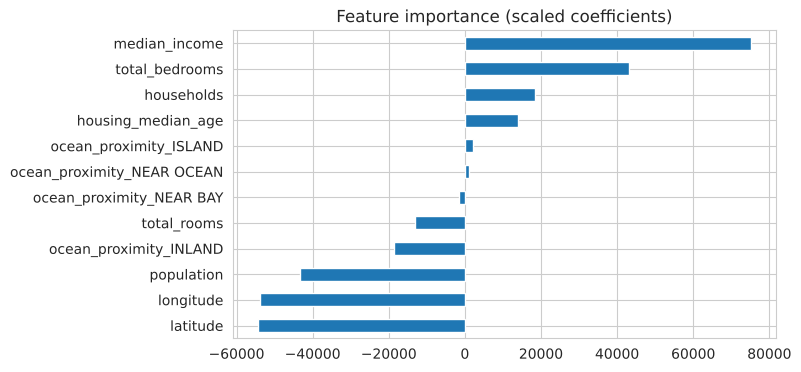

In [10]:
coef = pd.Series(lin.coef_, index=X.columns).sort_values()
coef.plot.barh(figsize=(7,4), title='Feature importance (scaled coefficients)'); plt.show()

## 7. Logistic Regression (binary classification)
Dataset: Breast Cancer (built into scikit-learn) — predict malignant (0) vs benign (1).

In [11]:
data = load_breast_cancer(as_frame=True)
Xc, yc = data.data, data.target
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.2, random_state=42, stratify=yc)
sc = StandardScaler().fit(Xc_tr)
log = LogisticRegression(max_iter=1000).fit(sc.transform(Xc_tr), yc_tr)
yc_pred = log.predict(sc.transform(Xc_te))
print('Accuracy:', round(accuracy_score(yc_te, yc_pred),4))
print(classification_report(yc_te, yc_pred, target_names=data.target_names))

Accuracy: 0.9825
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



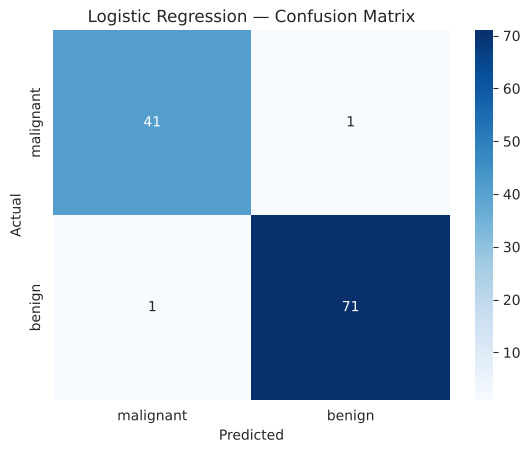

In [12]:
sns.heatmap(confusion_matrix(yc_te, yc_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Logistic Regression — Confusion Matrix'); plt.show()

## 8. Results explained

In [13]:
from IPython.display import Markdown
Markdown(f'''**Linear Regression (house prices)**
- **R² = {r2:.2f}** → the model explains about {r2*100:.0f}% of the variation in house prices.
- **MAE = ${mae:,.0f}** → on average predictions are off by about this much.
- **RMSE = ${rmse:,.0f}** → a bit higher than MAE because it punishes big errors more.
- Biggest drivers: `median_income` (higher income → higher price) and location (`latitude`/`longitude`, ocean proximity).
- Residual plot shows the model struggles with very expensive houses (prices are capped at $500k in this dataset). A simple linear model can't capture everything — tree-based models (Week 6) usually do better.

**Logistic Regression (cancer)** — accuracy **{accuracy_score(yc_te, yc_pred):.1%}**, with very few mistakes in the confusion matrix. A simple linear boundary works well on this dataset.''')

**Linear Regression (house prices)**
- **R² = 0.63** → the model explains about 63% of the variation in house prices.
- **MAE = $50,671** → on average predictions are off by about this much.
- **RMSE = $70,061** → a bit higher than MAE because it punishes big errors more.
- Biggest drivers: `median_income` (higher income → higher price) and location (`latitude`/`longitude`, ocean proximity).
- Residual plot shows the model struggles with very expensive houses (prices are capped at $500k in this dataset). A simple linear model can't capture everything — tree-based models (Week 6) usually do better.

**Logistic Regression (cancer)** — accuracy **98.2%**, with very few mistakes in the confusion matrix. A simple linear boundary works well on this dataset.